In [144]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [145]:
df = pd.read_pickle('../datasets/scifi_simulated.pkl')

df.head()

,# y_exit,z_exit,x_start,y_start,z_start,px_start,py_start,pz_start,reflCoCl,reflClCl,wl,gpsPosX,length_core,length_clad,rayleighScatterings
0,-0.026978,-0.061619,2400.019897,-0.051878,0.096635,0.948434,0.162628,-0.272077,3649.0,0.0,472.743103,2400.0,2530.557861,0.000000,0.0
1,-0.055254,0.050902,2400.000732,0.085666,0.015889,0.977825,-0.139056,-0.156593,2674.0,0.0,504.521210,2400.0,2454.456055,0.000000,0.0
2,0.049212,0.065583,2399.990967,0.006511,-0.025208,0.917937,-0.225034,0.326729,0.0,3894.0,442.621185,2400.0,2204.132568,381.522583,0.0
3,-0.018177,-0.106197,2400.062012,-0.043234,-0.098842,0.885576,0.074564,-0.458470,0.0,5517.0,484.213989,2400.0,2210.260498,466.030212,0.0
4,0.050591,0.043467,2400.000977,-0.004035,-0.069628,0.971248,-0.103995,-0.214154,2757.0,0.0,489.916565,2400.0,2470.986084,0.000000,0.0


In [146]:
# df.describe()

In [147]:
df.shape

(11795248, 15)

In [148]:
n_events = df.shape[0]

In [149]:
df.columns

Index(['# y_exit', 'z_exit', 'x_start', 'y_start', 'z_start', 'px_start',
       'py_start', 'pz_start', 'reflCoCl', 'reflClCl', 'wl', 'gpsPosX',
       'length_core', 'length_clad', 'rayleighScatterings'],
      dtype='object')

In [150]:
df = df.rename(columns={'# y_exit': 'y_exit'})

In [151]:
df['r_exit'] = np.sqrt(df['y_exit']**2 + df['z_exit']**2)

In [152]:
np.count_nonzero(df['r_exit'] > 0.125)/n_events

np.float64(0.17648658171494147)

In [153]:
df1 = df[df['r_exit'] < 0.125]
n_events1 = df1.shape[0]
print(n_events1)

9713545


In [154]:
np.count_nonzero(df1['rayleighScatterings'] != 0)/n_events1

np.float64(0.026145655370927917)

In [155]:
df2 = df1[df1['rayleighScatterings'] == 0]
n_events2 = df2.shape[0]
print(n_events2)

9459578


In [156]:
df2['theta'] = np.degrees(np.acos(df2['px_start']))

In [157]:
df_core = df2[df2['length_clad'] == 0]
df_cladding = df2[df2['length_clad'] > 0]

core_photons = df_core.shape[0]
clad_photons = df_cladding.shape[0]

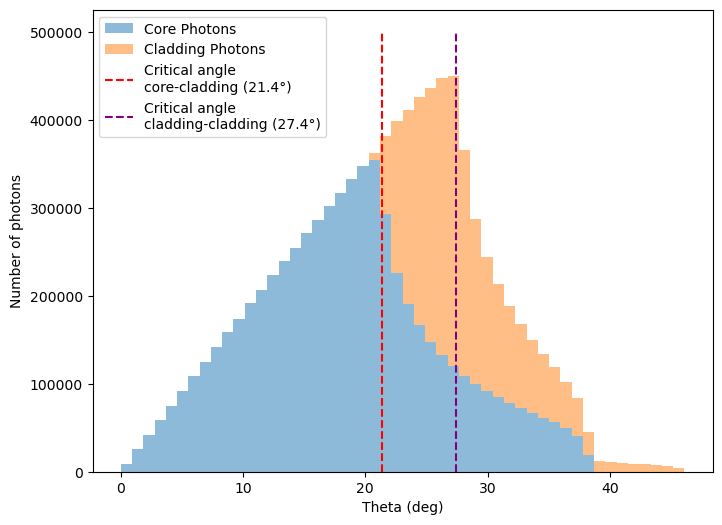

In [158]:
plt.figure(figsize=(8, 6))
plt.hist([df_core['theta'], df_cladding['theta']], bins=50, alpha=0.5, label=['Core Photons', 'Cladding Photons'], stacked=True)
plt.vlines(21.4, 0, 5e5, colors='red', linestyles='dashed', label='Critical angle\ncore-cladding (21.4°)')
plt.vlines(27.4, 0, 5e5, colors='purple', linestyles='dashed', label='Critical angle\ncladding-cladding (27.4°)')
plt.xlabel('Theta (deg)')
plt.ylabel('Number of photons')
plt.legend(loc='upper left')
plt.show()

In [159]:
r_core = 0.11

def r_min(x, theta, N):
    return np.sqrt(r_core**2 - (x * np.tan(np.radians(theta)))**2 / (2 * N)**2)

In [162]:
df_core['r_min'] = r_min(df_core['x_start'], df_core['theta'], df_core['reflCoCl'])

ValueError: autodetected range of [nan, nan] is not finite

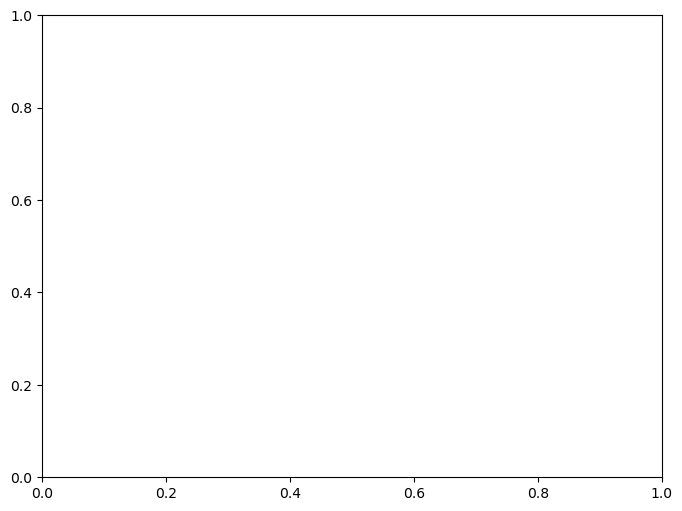

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist2d(df_core['r_min'], df_core['theta'], bins=50, alpha=0.7, label='Core photons')
plt.hist2d(df_cladding['r_min'], df_cladding['theta'], bins=50, alpha=0.7, label='Cladding photons')
plt.vlines(21.4, 0, 90, colors='red', linestyles='dashed', label='Critical angle\ncore-cladding (21.4°)')
plt.vlines(27.4, 0, 90, colors='purple', linestyles='dashed', label='Critical angle\ncladding-cladding (27.4°)')
plt.xlabel('Minimum radius (cm)')
plt.ylabel('Theta (degrees)')
plt.legend(loc='upper right')
plt.show()